<a href="https://colab.research.google.com/github/T-Antonis/ConvVAE_Pneumonia_Detection/blob/main/Pneumonia_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Anomaly Detection and classification using ConvVAE

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torchvision.transforms import v2


In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os
print(os.listdir(path))

['chest_xray']


In [ ]:
base_path = "/kaggle/input/chest-xray-pneumonia"
data_path = os.path.join(base_path, "chest_xray")

print(os.listdir(data_path))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:
train_dir = os.path.join(data_path, "train")
test_dir = os.path.join(data_path, "test")       #different directories for each folder
val_dir = os.path.join(data_path, "val")

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

Device cuda


In [ ]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.4),
    v2.RandomRotation(degrees=10),
    v2.Grayscale(num_output_channels=1),                   #Augmentation for train data (normal pictures)
    v2.Resize((128, 128)),
    v2.ColorJitter(brightness=0.05, contrast=0.05),
    v2.ToTensor(),
])

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
eval_transform = v2.Compose([
    v2.Resize((128, 128)),
    v2.Grayscale(num_output_channels=1),        #Transform for the rest data
    v2.ToTensor(),
])

In [ ]:
import shutil


# initial paths
train_normal_src = os.path.join(train_dir, "NORMAL")
train_pneumonia_src = os.path.join(train_dir, "PNEUMONIA")

# new paths
# Changed new_root to a writable directory
new_root = os.path.join("/content/", "separated_train")
train_normal_dst = os.path.join(new_root, "train_normal", "NORMAL")
train_pneumonia_dst = os.path.join(new_root, "train_pneumonia", "PNEUMONIA")

# folder creation
os.makedirs(train_normal_dst, exist_ok=True)
os.makedirs(train_pneumonia_dst, exist_ok=True)

# copying NORMAL
for fname in os.listdir(train_normal_src):
    src = os.path.join(train_normal_src, fname)
    dst = os.path.join(train_normal_dst, fname)
    if os.path.isfile(src):
        shutil.copy2(src, dst)

# copying PNEUMONIA
for fname in os.listdir(train_pneumonia_src):
    src = os.path.join(train_pneumonia_src, fname)
    dst = os.path.join(train_pneumonia_dst, fname)
    if os.path.isfile(src):
        shutil.copy2(src, dst)

print("Done.")
print("train_normal path:", os.path.join(new_root, "train_normal"))
print("train_pneumonia path:", os.path.join(new_root, "train_pneumonia"))

Done.
train_normal path: /content/separated_train/train_normal
train_pneumonia path: /content/separated_train/train_pneumonia


In [ ]:
train_normal_dataset = datasets.ImageFolder(
    root=os.path.join(new_root, "train_normal"),
    transform=train_transform)

test_dataset = datasets.ImageFolder(
    root = test_dir,
    transform = eval_transform)

val_dataset = datasets.ImageFolder(
    root = val_dir,
    transform = eval_transform)

In [ ]:
# img, label = train_normal_dataset[0]

# fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# for ax in axes.flatten():
#     aug_img, _ = train_normal_dataset[0]   # ίδιο index, νέο random augment κάθε φορά
#     ax.imshow(aug_img.squeeze(0), cmap="gray")
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

In [ ]:
#Convolutional Variational Autoencoder


import torch.nn as nn

class ConvVAE(nn.Module):
  def __init__(self, latent_dim=64):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), #128 to 64
        nn.ReLU(),

        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), #64 to 32
        nn.ReLU(),

        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), #32 to 16
        nn.ReLU(),

        nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), #16 to 8
        nn.ReLU(),

        nn.Flatten()
    )

    self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
    self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)

    self.decoder_input = nn.Linear(latent_dim, 256 * 8 * 8)

    self.decoder = nn.Sequential(
        nn.Unflatten(1, (256, 8, 8)),
        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), #8 to 16
        nn.ReLU(),

        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), #16 to 32
        nn.ReLU(),

        nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), #32 to 64
        nn.ReLU(),

        nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), #64 to 128
        nn.Sigmoid()
    )


  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x):
    h = self.encoder(x)
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    z = self.reparameterize(mu, logvar)
    x_hat = self.decoder(self.decoder_input(z))
    return x_hat, mu, logvar

In [ ]:
#Loss function

import torch.nn.functional as F

def loss_function(x_hat, x, mu, logvar):
  recon_loss = F.l1_loss(x_hat, x, reduction="mean")
  kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
  total_loss = recon_loss + (1e-3) * kl_loss
  return total_loss, recon_loss, kl_loss

In [ ]:
import torch.optim as optim

model = ConvVAE(latent_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

#data loaders
train_loader = DataLoader(train_normal_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



In [ ]:
#Model Training

num_epochs = 50

train_losses = []
train_recon_losses = []
train_kl_losses = []

model.train()

for epoch in range(num_epochs):
  epoch_loss = 0.0
  epoch_recon = 0.0
  epoch_kl = 0.0

  for x, _ in train_loader:
    x = x.to(device)

    optimizer.zero_grad()
    x_hat, mu, logvar = model(x)
    loss, recon_loss, kl_loss = loss_function(x_hat, x, mu, logvar)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_recon += recon_loss.item()
    epoch_kl += kl_loss.item()

  epoch_loss /= len(train_loader)
  epoch_recon /= len(train_loader)
  epoch_kl /= len(train_loader)

  train_losses.append(epoch_loss)
  train_recon_losses.append(epoch_recon)
  train_kl_losses.append(epoch_kl)

  print(f"Epoch [{epoch+1}/{num_epochs}] | Total: {epoch_loss:.4f} | Recon: {epoch_recon:.4f} | KL: {epoch_kl:.4f}")

Epoch [1/50] | Total: 0.1827 | Recon: 0.1822 | KL: 0.4427
Epoch [2/50] | Total: 0.1648 | Recon: 0.1638 | KL: 1.0011
Epoch [3/50] | Total: 0.1592 | Recon: 0.1579 | KL: 1.2508
Epoch [4/50] | Total: 0.1562 | Recon: 0.1548 | KL: 1.3558
Epoch [5/50] | Total: 0.1541 | Recon: 0.1527 | KL: 1.4551
Epoch [6/50] | Total: 0.1531 | Recon: 0.1515 | KL: 1.5364
Epoch [7/50] | Total: 0.1523 | Recon: 0.1507 | KL: 1.5826
Epoch [8/50] | Total: 0.1521 | Recon: 0.1505 | KL: 1.5820
Epoch [9/50] | Total: 0.1506 | Recon: 0.1490 | KL: 1.6401
Epoch [10/50] | Total: 0.1503 | Recon: 0.1486 | KL: 1.6505
Epoch [11/50] | Total: 0.1502 | Recon: 0.1486 | KL: 1.6513
Epoch [12/50] | Total: 0.1493 | Recon: 0.1476 | KL: 1.6926
Epoch [13/50] | Total: 0.1490 | Recon: 0.1472 | KL: 1.7101
Epoch [14/50] | Total: 0.1488 | Recon: 0.1471 | KL: 1.7218
Epoch [15/50] | Total: 0.1481 | Recon: 0.1464 | KL: 1.7202
Epoch [16/50] | Total: 0.1479 | Recon: 0.1462 | KL: 1.7582
Epoch [17/50] | Total: 0.1477 | Recon: 0.1459 | KL: 1.7659
Epoch 

In [ ]:
#Importing Drive-necessary for saving and loading model

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/convvae_best.pth")

In [ ]:
model = ConvVAE(latent_dim=64).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/convvae_best.pth"))
model.eval()

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=16384, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=16384, out_features=64, bias=True)
  (decoder_input): Linear(in_features=64, out_features=16384, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 8, 8))
    (1): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2,

In [ ]:
#Model Evaluation using validation dataset

def evaluate_val(model, loader, device, loss_function):
    model.eval()

    val_total_loss = 0.0
    val_recon_loss = 0.0
    val_kl_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            x_hat, mu, logvar = model(x)
            loss, recon_loss, kl_loss = loss_function(x_hat, x, mu, logvar)

            val_total_loss += loss.item()
            val_recon_loss += recon_loss.item()
            val_kl_loss += kl_loss.item()

    val_total_loss /= len(loader)
    val_recon_loss /= len(loader)
    val_kl_loss /= len(loader)

    print(f"Val Total Loss: {val_total_loss:.4f}")
    print(f"Val Recon Loss: {val_recon_loss:.4f}")
    print(f"Val KL Loss: {val_kl_loss:.4f}")

In [ ]:
evaluate_val(model, val_loader, device, loss_function)

Val Total Loss: 0.0784
Val Recon Loss: 0.0766
Val KL Loss: 1.8536


In [ ]:
#Anomaly Scores

import numpy as np

def get_anomaly_scores(model, loader, device):
    model.eval()

    scores = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            x_hat, mu, logvar = model(x)

            batch_scores = -torch.mean(torch.abs(x - x_hat), dim=(1, 2, 3))

            scores.extend(batch_scores.cpu().numpy())
            labels.extend(y.cpu().numpy())

    return np.array(scores), np.array(labels)

In [ ]:
val_scores, val_labels = get_anomaly_scores(model, val_loader, device)

In [ ]:
def get_class_scores(scores, labels, class_to_idx):
    normal_scores = scores[labels == class_to_idx["NORMAL"]]
    pneumonia_scores = scores[labels == class_to_idx["PNEUMONIA"]]
    return normal_scores, pneumonia_scores

In [ ]:
#AUC score

from sklearn.metrics import roc_auc_score

def compute_roc_auc(score, labels, class_to_idx):
  binary_labels = (labels == class_to_idx["PNEUMONIA"]).astype(int)
  auc = roc_auc_score(binary_labels, score)
  return auc

In [ ]:
normal_scores, pneumonia_scores = get_class_scores(val_scores, val_labels, val_dataset.class_to_idx)
val_auc = compute_roc_auc(val_scores, val_labels, val_dataset.class_to_idx)

In [ ]:
print(f"Validation AUC: {val_auc:.4f}")

Validation AUC: 0.5469


In [ ]:
print(f"normal scores mean: {normal_scores.mean():.4f}")
print(f"pneumonia scores mean: {pneumonia_scores.mean():.4f}")

normal scores mean: -0.0791
pneumonia scores mean: -0.0738


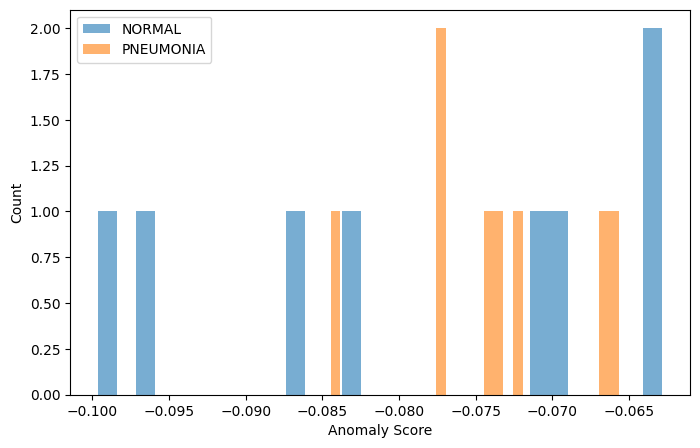

In [ ]:
#Histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(normal_scores, bins=30, alpha=0.6, label="NORMAL")
plt.hist(pneumonia_scores, bins=30, alpha=0.6, label="PNEUMONIA")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
#Defining threshold and performing classification based on it

from sklearn.metrics import confusion_matrix, classification_report

threshold = -0.0775
print("Threshold:", threshold)

binary_labels = (val_labels == val_dataset.class_to_idx["PNEUMONIA"]).astype(int)
val_preds = (val_scores > threshold).astype(int)

print(confusion_matrix(binary_labels, val_preds))
print(classification_report(binary_labels, val_preds, target_names=["NORMAL", "PNEUMONIA"]))

Threshold: -0.0775
[[4 4]
 [1 7]]
              precision    recall  f1-score   support

      NORMAL       0.80      0.50      0.62         8
   PNEUMONIA       0.64      0.88      0.74         8

    accuracy                           0.69        16
   macro avg       0.72      0.69      0.68        16
weighted avg       0.72      0.69      0.68        16



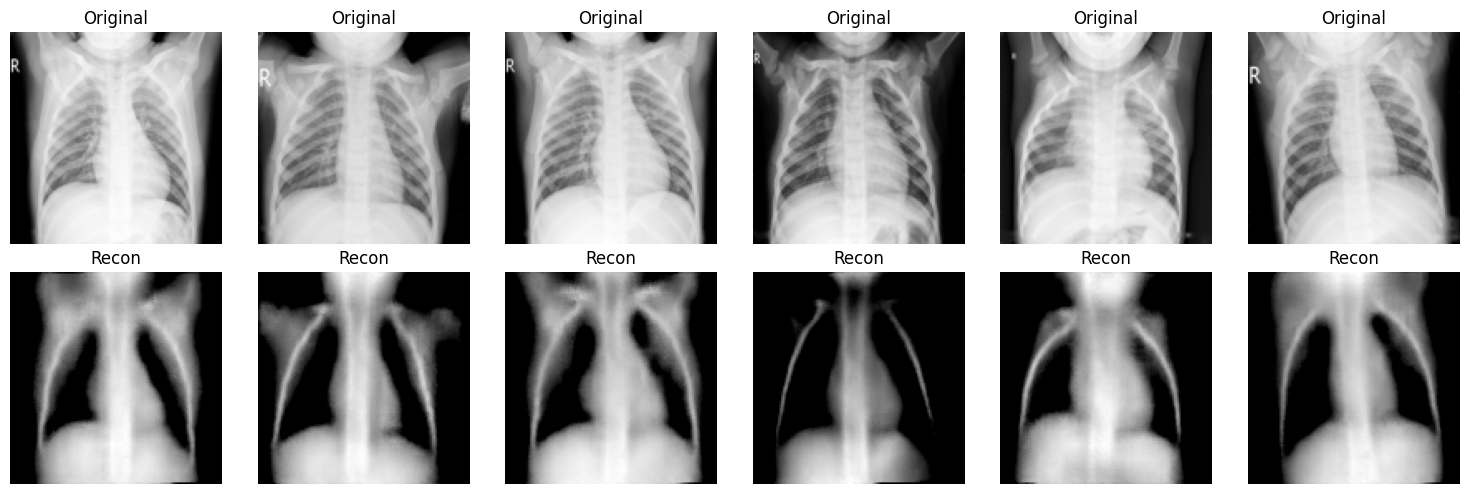

In [ ]:
#Evaluating model's reconstruction performance

model.eval()

x, y = next(iter(val_loader))
x = x.to(device)

with torch.no_grad():
    x_hat, mu, logvar = model(x)

x = x.cpu()
x_hat = x_hat.cpu()

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for i in range(6):
    axes[0, i].imshow(x[i].squeeze(0), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(x_hat[i].squeeze(0), cmap="gray")
    axes[1, i].set_title("Recon")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Testing the model on the test dataset

test_scores, test_labels = get_anomaly_scores(model, test_loader, device)

normal_idx = test_dataset.class_to_idx["NORMAL"]
pneumonia_idx = test_dataset.class_to_idx["PNEUMONIA"]

test_normal_scores, test_pneumonia_scores = get_class_scores(test_scores, test_labels, test_dataset.class_to_idx)

print("Test normal mean score:", test_normal_scores.mean())
print("Test pneumonia mean score:", test_pneumonia_scores.mean())

Test normal mean score: -0.08517997
Test pneumonia mean score: -0.07704977


In [ ]:
test_auc = compute_roc_auc(test_scores, test_labels, test_dataset.class_to_idx)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.6928


In [ ]:
binary_labels = (test_labels == test_dataset.class_to_idx["PNEUMONIA"]).astype(int)
test_preds = (test_scores > -0.0775).astype(int)

print(confusion_matrix(binary_labels, test_preds))
print(classification_report(binary_labels, test_preds, target_names=["NORMAL", "PNEUMONIA"]))

[[177  57]
 [181 209]]
              precision    recall  f1-score   support

      NORMAL       0.49      0.76      0.60       234
   PNEUMONIA       0.79      0.54      0.64       390

    accuracy                           0.62       624
   macro avg       0.64      0.65      0.62       624
weighted avg       0.68      0.62      0.62       624



##ResNet classification with transfer learning

In [23]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import os

In [24]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [25]:
base_path = "/kaggle/input/chest-xray-pneumonia"
data_path = os.path.join(base_path, "chest_xray")

In [26]:
train_dir = os.path.join(data_path, "train")
test_dir = os.path.join(data_path, "test")       #different directories for each folder
val_dir = os.path.join(data_path, "val")

In [27]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

Device cuda


In [28]:
train_transform = v2.Compose([
    v2.Grayscale(num_output_channels=3),
    v2.Resize((224, 224)),
    v2.RandomRotation(degrees=5),
    v2.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.97, 1.03)
    ),
    v2.ColorJitter(brightness=0.05, contrast=0.05),
    v2.ToTensor(),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = v2.Compose([
    v2.Grayscale(num_output_channels=3),
    v2.Resize((224, 224)),
    v2.ToTensor(),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [29]:
train_dataset = datasets.ImageFolder(root = train_dir, transform = train_transform)
val_dataset = datasets.ImageFolder(root = val_dir, transform = eval_transform)
test_dataset = datasets.ImageFolder(root = test_dir, transform = eval_transform)

In [30]:
#data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [32]:
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np



resnet_model = models.resnet18(pretrained=True)

for name, param in resnet_model.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

resnet_model.fc = nn.Sequential(                      #Changing layer4 and fc head of ResNet18
    nn.Dropout(0.5),                                  # Drops 50% of neurons for regularization
    nn.Linear(resnet_model.fc.in_features, 2)
)


resnet_model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=0.001)


epochs = 5

resnet_model.train()

for epoch in range(epochs):
  running_loss = 0.0
  correct = 0
  total = 0

  for x,y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()

    outputs = resnet_model(x)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    _, preds = torch.max(outputs, 1)
    correct += (preds == y).sum().item()
    total += y.size(0)

  epoch_loss = running_loss / len(train_loader)
  epoch_acc = correct / total

  print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

Epoch [1/5] | Train Loss: 0.1556 | Train Acc: 0.9457
Epoch [2/5] | Train Loss: 0.0753 | Train Acc: 0.9712
Epoch [3/5] | Train Loss: 0.0613 | Train Acc: 0.9783
Epoch [4/5] | Train Loss: 0.0494 | Train Acc: 0.9803
Epoch [5/5] | Train Loss: 0.0314 | Train Acc: 0.9887


In [33]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

resnet_model.eval()

val_loss = 0.0
val_labels = []
val_preds = []
val_probs = []

with torch.no_grad():
  for x, y in val_loader:
    x, y = x.to(device), y.to(device)

    outputs = resnet_model(x)
    loss = criterion(outputs, y)

    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

    val_loss += loss.item()
    val_labels.extend(y.cpu().numpy())
    val_preds.extend(preds.cpu().numpy())
    val_probs.extend(probs[:, 1].cpu().numpy())

val_loss /= len(val_loader)
val_auc = roc_auc_score(val_labels, val_probs)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation AUC: {val_auc:.4f}")
print(confusion_matrix(val_labels, val_preds))
print(classification_report(val_labels, val_preds, target_names=["NORMAL", "PNEUMONIA"]))

Validation Loss: 0.4124
Validation AUC: 1.0000
[[7 1]
 [0 8]]
              precision    recall  f1-score   support

      NORMAL       1.00      0.88      0.93         8
   PNEUMONIA       0.89      1.00      0.94         8

    accuracy                           0.94        16
   macro avg       0.94      0.94      0.94        16
weighted avg       0.94      0.94      0.94        16



In [34]:
test_loss = 0.0
test_labels = []
test_preds = []
test_probs = []

with torch.no_grad():
  for x, y in test_loader:
    x, y = x.to(device), y.to(device)

    outputs = resnet_model(x)
    loss = criterion(outputs, y)

    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

    test_loss += loss.item()
    test_labels.extend(y.cpu().numpy())
    test_preds.extend(preds.cpu().numpy())
    test_probs.extend(probs[:, 1].cpu().numpy())

test_loss /= len(test_loader)
test_auc = roc_auc_score(test_labels, test_probs)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(confusion_matrix(test_labels, test_preds))
print(classification_report(test_labels, test_preds, target_names=["NORMAL", "PNEUMONIA"]))


Test Loss: 1.0649
Test AUC: 0.9596
[[125 109]
 [  3 387]]
              precision    recall  f1-score   support

      NORMAL       0.98      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624

